# Madhav E-Commerce Sales Analysis and Dashboard

## Imports
Libraries for data access, analysis, visualization, and dashboarding.

In [133]:
# Data access + analysis stack
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Interactive visuals + dashboard components
import io
import base64
import plotly.express as px
import plotly.graph_objs as go
from dash import Dash, html, dcc, Input, Output

## Load Madhav Dataset (Kaggle)
Download the Orders and Details tables from the Kaggle dataset.

### Load `Orders` table
Order-level records with dates, customer info, and order attributes.

In [110]:
# Load Orders table from the Kaggle dataset
file_path = "Orders.csv"

Orders_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "amitkumar209/madhav-e-commerce-sales-dataset",
    file_path
)

# Quick look at the schema and first rows
Orders_df.head()

,Order ID,Order Date,CustomerName,State,City
0,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura
1,B-25993,03-02-2018,Madhav,Delhi,Delhi
2,B-25973,24-01-2018,Madan Mohan,Uttar Pradesh,Mathura
3,B-25923,27-12-2018,Gopal,Maharashtra,Mumbai
4,B-25757,21-08-2018,Vishakha,Madhya Pradesh,Indore


### Load `Details` table
Line-item records with product, category, sales, and profit fields.

In [111]:
# Load line-item Details table
file_path = "Details.csv"

Details_df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "amitkumar209/madhav-e-commerce-sales-dataset",
    file_path,
)

# Quick look at the schema and first rows
Details_df.head()

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-25681,1096,658,7,Electronics,Electronic Games,COD
1,B-26055,5729,64,14,Furniture,Chairs,EMI
2,B-25955,2927,146,8,Furniture,Bookcases,EMI
3,B-26093,2847,712,8,Electronics,Printers,Credit Card
4,B-25602,2617,1151,4,Electronics,Phones,Credit Card


## Merge Datasets
Join on `Order ID` and confirm the combined schema before analysis.

In [93]:
# Join orders with item details on Order ID
df = pd.merge(Orders_df, Details_df, on="Order ID")
df.head()

,Order ID,Order Date,CustomerName,State,City,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode
0,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,5729,64,14,Furniture,Chairs,EMI
1,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,671,114,9,Electronics,Phones,Credit Card
2,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,443,11,1,Clothing,Saree,COD
3,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,57,7,2,Clothing,Shirt,UPI
4,B-26055,10-03-2018,Harivansh,Uttar Pradesh,Mathura,227,48,5,Clothing,Stole,COD


In [94]:
# Review column types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1500 non-null   object
 1   Order Date    1500 non-null   object
 2   CustomerName  1500 non-null   object
 3   State         1500 non-null   object
 4   City          1500 non-null   object
 5   Amount        1500 non-null   int64 
 6   Profit        1500 non-null   int64 
 7   Quantity      1500 non-null   int64 
 8   Category      1500 non-null   object
 9   Sub-Category  1500 non-null   object
 10  PaymentMode   1500 non-null   object
dtypes: int64(3), object(8)
memory usage: 129.0+ KB


## Data Cleaning
Parse dates and create time-based features for trend analysis.

### Convert `Order Date` to datetime
Ensure dates are parsed correctly for sorting, grouping, and resampling.

In [95]:
# Parse order date for time-based analysis
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Order Date"].head()

0   2018-03-10
1   2018-03-10
2   2018-03-10
3   2018-03-10
4   2018-03-10
Name: Order Date, dtype: datetime64[ns]

#### Create an `Order Month` column
Store month names for seasonal and monthly trend charts.

In [96]:
# Extract month name for trend charts
df["Order Month"] = pd.to_datetime(df["Order Date"]).dt.strftime("%b")
df["Order Month"].sample(5)

990    Sep
465    Nov
667    Mar
394    Apr
440    Jan
Name: Order Month, dtype: object

#### Create `Quater` (quarter) column
Derive quarter values for higher-level seasonal grouping.

In [97]:
# Extract quarter for seasonal grouping
df["Quater"] = pd.to_datetime(df["Order Date"]).dt.quarter
df["Quater"].sample(5)

829     2
382     3
826     2
213     3
1401    4
Name: Quater, dtype: int32

## Analysis
This section explains the main results in simple terms. Each chart focuses on one question (profit, revenue, customers, or payment behavior).
Read the short notes before each chart to understand what the plot is showing and why it matters.

### Key Performance Indicators (KPIs)
KPIs are quick summary numbers. They help you understand the overall business performance before looking at detailed charts.
Each KPI below is calculated from the full dataset.

#### Total Revenue
Total money earned from all orders.
If this number is high, it means sales volume is strong.

In [98]:
total_revenue = df['Amount'].sum()
print(f"Total Revenue: ₹{total_revenue/100000:.2f}L")

Total Revenue: ₹4.38L


#### Total Profit
Profit is revenue minus costs.
A positive total profit means the business earned more than it spent.

In [99]:
total_profit = df['Profit'].sum()
print(f"Total Profit: ₹{total_profit:,}")

Total Profit: ₹36,963


#### Total Quantity Sold
Total number of items sold across all orders.
This shows sales volume regardless of price.

In [100]:
total_quantity = df['Quantity'].sum()
print(f"Total Quantity Sold: {total_quantity:,}")

Total Quantity Sold: 5,615


#### Average Order Value (AOV)
Average revenue per unit sold.
A higher AOV often means customers are buying higher value items or bundles.

In [131]:
aov = df['Amount'].sum() / df['Quantity'].sum()
print(f"Average Order Value: ₹{aov:.2f}")

Average Order Value: ₹77.96


### Exploratory Data Analysis (EDA)
EDA helps you find patterns and differences in the data.
The charts below break the data by time, product type, location, and payment method.

#### Profit by Month
Shows how profit changes month by month.
Green bars mean profit and red bars mean loss, so you can quickly spot weak months.

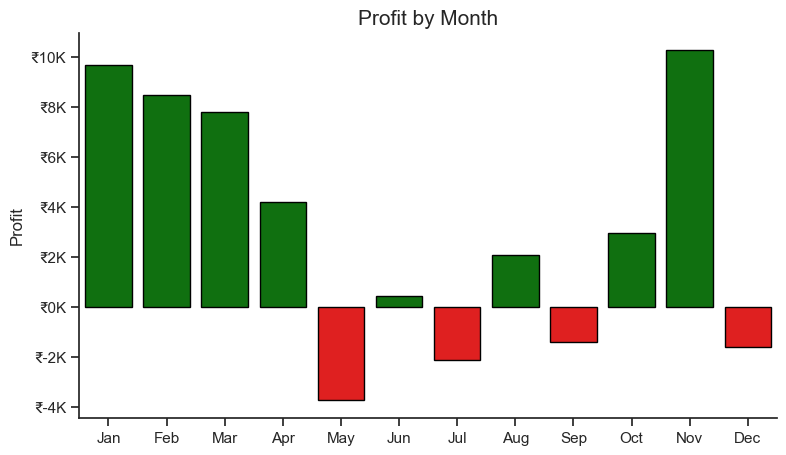

In [102]:
df_month_profit = df.groupby("Order Month")['Profit'].sum().reset_index()
df_month_profit['Month_No'] = pd.to_datetime(df_month_profit['Order Month'], format='%b').dt.month
df_month_profit.sort_values('Month_No', inplace=True)
df_month_profit.drop("Month_No", axis=1, inplace=True)

plt.figure(figsize=(9, 5))
sns.set_theme(style='ticks')

bar_color = ["green" if profit >= 0 else "red" for profit in df_month_profit['Profit']]

sns.barplot(data = df_month_profit,
            x = 'Order Month',
            y = "Profit",
            edgecolor = 'black',
            palette=bar_color)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"₹{int(y/1000)}K"))

plt.title("Profit by Month", fontsize=15)
plt.ylabel("Profit")
plt.xlabel("")

sns.despine()
plt.show()

#### Profit by Sub-Category
Compares profit across product sub-categories.
This helps identify which product types contribute most to profit.

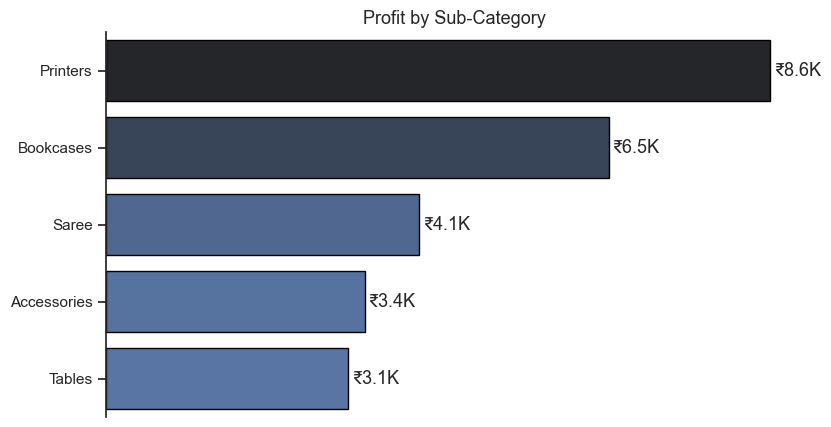

In [103]:
df_sub_category_profit = df.groupby(['Sub-Category'])['Profit'].sum().sort_values(ascending=False).head().reset_index()

plt.figure(figsize=(9, 5))
sns.set_theme(style='ticks')

sns.barplot(data = df_sub_category_profit,
            x = "Profit",
            y = "Sub-Category",
            hue = "Profit",
            palette = "dark:b_r",
            edgecolor = "black")

plt.xticks([])
for i, profit in enumerate(df_sub_category_profit['Profit']):
    plt.text(profit + 50, i, f"₹{profit/1000:,.1f}K", va='center', fontsize=13)

plt.title("Profit by Sub-Category", fontsize=13)
plt.xlabel("")
plt.ylabel("")

plt.legend().remove()
sns.despine(bottom=True)
plt.show()

#### Top Revenue States
Shows which states bring in the most revenue.
Focus on these states for marketing or supply planning.

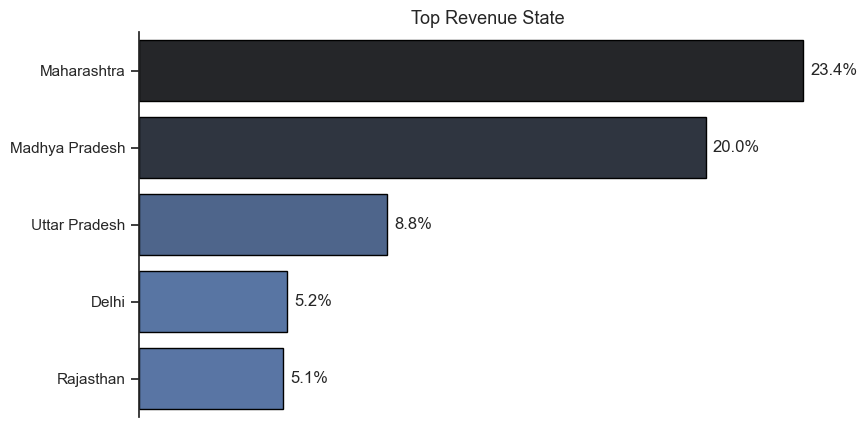

In [128]:
df_top_revenue_states = df.groupby('State')['Amount'].sum().sort_values(ascending=False).head().reset_index()
df_top_revenue_states['Percent'] = df_top_revenue_states['Amount'] / df["Amount"].sum() * 100

plt.figure(figsize=(9, 5))
sns.set_theme(style="ticks")

sns.barplot(data = df_top_revenue_states,
            x = "Percent",
            y = "State",
            hue = "Amount",
            palette = "dark:b_r",
            edgecolor = "black")

plt.xticks([])
for i, per in enumerate(df_top_revenue_states['Percent']):
    plt.text(per + 0.25, i, f"{per:.1f}%", va='center')
    
plt.title("Top Revenue State", fontsize=13)
plt.xlabel("")
plt.ylabel("")

plt.legend().remove()
sns.despine(bottom=True)
plt.show()

#### Quantity Sold by Category
Pie chart showing the share of total units sold by category.
Use this to understand the product mix.

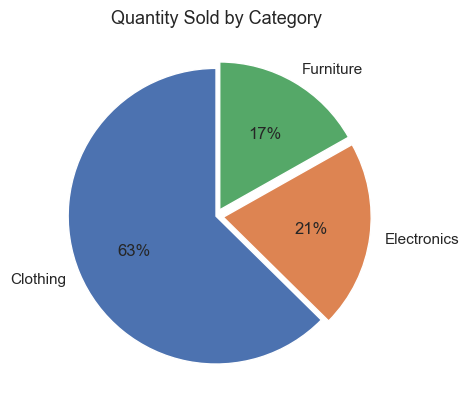

In [105]:
df_category_quantity = df.groupby('Category')['Quantity'].sum().reset_index()

plt.pie(df_category_quantity['Quantity'],
        labels = df_category_quantity['Category'],
        startangle = 90,
        autopct = '%1.0f%%',
        explode = [0, 0.05, 0.05])

plt.title("Quantity Sold by Category", fontsize=13)
plt.show()

#### Payment Mode Distribution
Shows how customers prefer to pay (e.g., COD, UPI, cards).
This helps plan payment options and promotions.

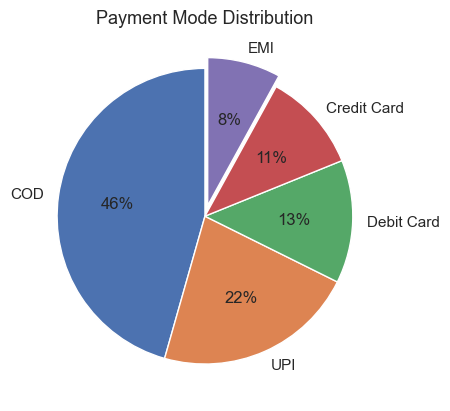

In [106]:
df_payment_mode = df["PaymentMode"].value_counts().reset_index()

plt.pie(df_payment_mode['count'],
        labels = df_payment_mode['PaymentMode'],
        startangle = 90,
        autopct = '%1.0f%%',
        explode = [0, 0, 0, 0, 0.075])

plt.title("Payment Mode Distribution", fontsize=13)
plt.show()

#### Top 5 Customers
Highlights the customers with the highest total spend.
These customers are important for retention and loyalty programs.

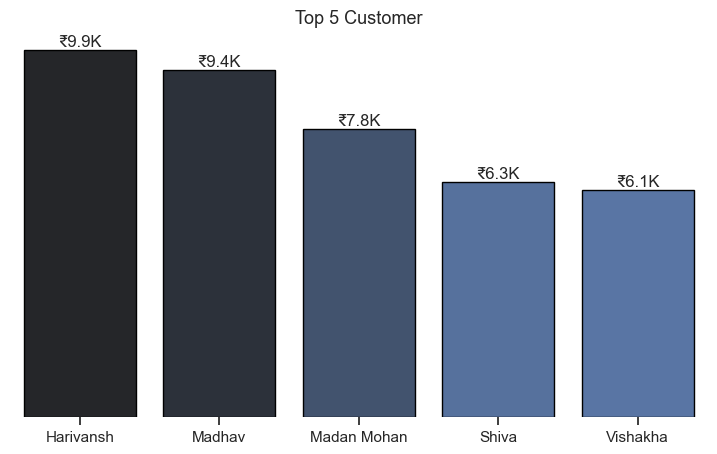

In [132]:
df_top_customers = df.groupby("CustomerName")['Amount'].sum().sort_values(ascending=False).head().reset_index()

plt.figure(figsize=(9, 5))
sns.set_theme(style="ticks")

sns.barplot(data = df_top_customers,
            x = "CustomerName",
            y = "Amount",
            hue = "Amount",
            palette = "dark:b_r",
            edgecolor = "black")

plt.yticks([])
for i, amt in enumerate(df_top_customers['Amount']):
    plt.text(i, amt + 100, f"₹{amt/1000:.1f}K", ha='center') 
    
plt.title("Top 5 Customer", fontsize=13)
plt.xlabel("")
plt.ylabel("")

plt.legend().remove()
sns.despine(bottom=True, left=True)
plt.show()

## Static Dashboard

This dashboard gives a one-page snapshot of Madhav E-Commerce performance.

- **Top row (left to right):**
  - Profit trend by month
  - Most profitable sub-categories
  - Highest revenue states
- **Bottom row (left to right):**
  - Quantity share by category
  - Payment mode distribution
  - Top 5 customers by revenue

#### How to read this dashboard
- Use it for a **quick executive summary** before deep-diving into individual charts.
- Compare **profitability**, **geographic concentration**, and **customer/payment behavior** in one view.
- Treat this as a **static KPI board**; the interactive dashboard below is better for filtering by category and quarter.

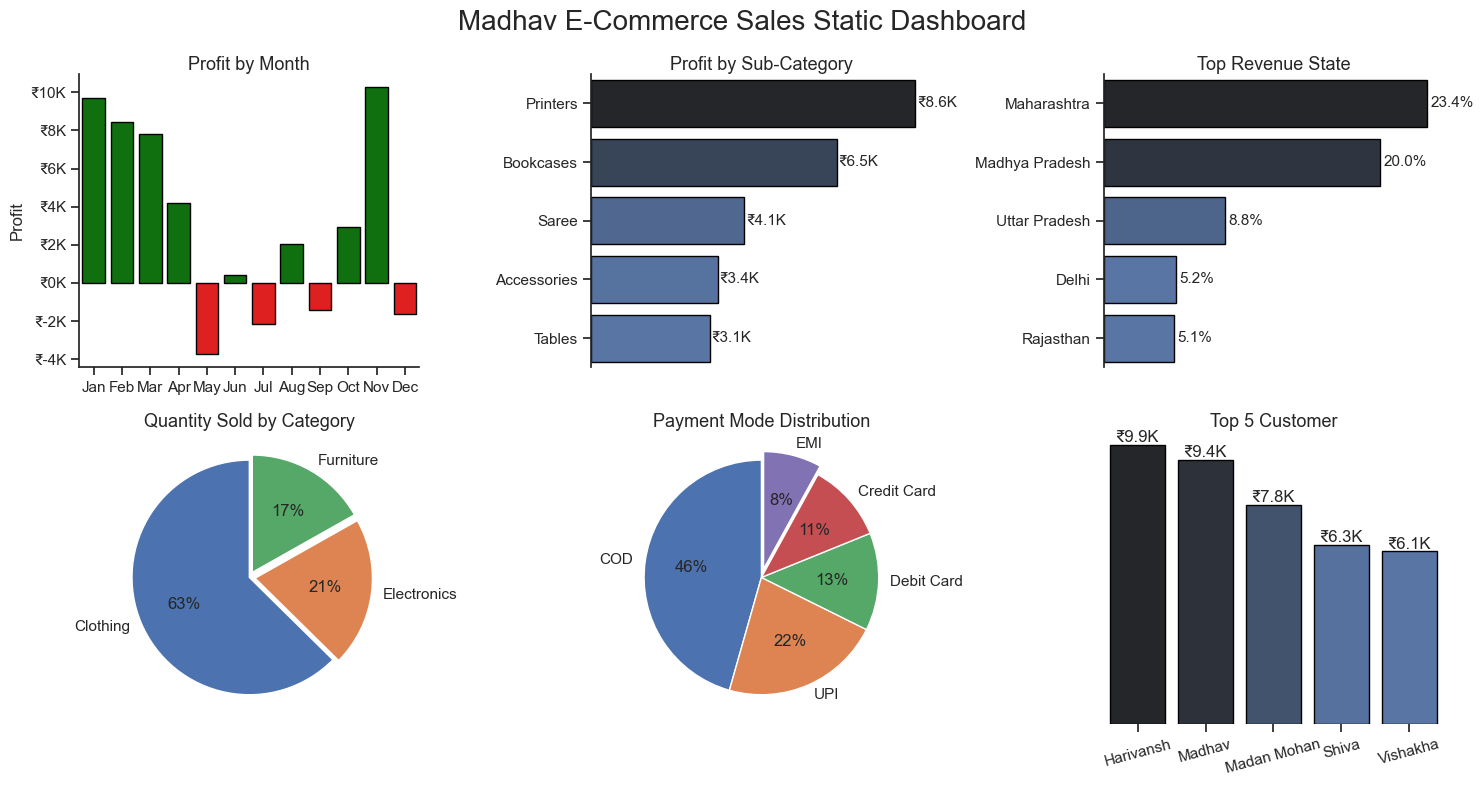

In [129]:
fig, ax = plt.subplots(2, 3, figsize=(15, 8))
ax = ax.flatten()
sns.set_theme(style='ticks')

# Profit by Month
sns.set_theme(style='ticks')
bar_color = ["green" if profit >= 0 else "red" for profit in df_month_profit['Profit']]

sns.barplot(data = df_month_profit,
            x = 'Order Month',
            y = "Profit",
            edgecolor = 'black',
            palette=bar_color,
            ax = ax[0])

ax[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f"₹{int(y/1000)}K"))

ax[0].set_title("Profit by Month", fontsize=13, pad=3)
ax[0].set_ylabel("Profit")
ax[0].set_xlabel("")

# Profit by Sub-Category
sns.set_theme(style='ticks')
sns.barplot(data = df_sub_category_profit,
            x = "Profit",
            y = "Sub-Category",
            hue = "Profit",
            palette = "dark:b_r",
            edgecolor = "black",
            ax = ax[1])

ax[1].set_xticks([])
for i, profit in enumerate(df_sub_category_profit['Profit']):
    ax[1].text(profit + 50, i, f"₹{profit/1000:,.1f}K", va='center', fontsize=11)

ax[1].set_title("Profit by Sub-Category", fontsize=13, pad=3)
ax[1].set_xlabel("")
ax[1].set_ylabel("")
ax[1].legend().remove()

# Top Revenue States
sns.set_theme(style="ticks")
sns.barplot(data = df_top_revenue_states,
            x = "Percent",
            y = "State",
            hue = "Amount",
            palette = "dark:b_r",
            edgecolor = "black",
            ax = ax[2])

ax[2].set_xticks([])
for i, per in enumerate(df_top_revenue_states['Percent']):
    ax[2].text(per + 0.25, i, f"{per:.1f}%", va='center', fontsize=11)
    
ax[2].set_title("Top Revenue State", fontsize=13, pad=3)
ax[2].set_xlabel("")
ax[2].set_ylabel("")
ax[2].legend().remove()

# Category Sold Distribution
ax[3].pie(df_category_quantity['Quantity'],
        labels = df_category_quantity['Category'],
        startangle = 90,
        autopct = '%1.0f%%',
        explode = [0, 0.05, 0.05])

ax[3].set_title("Quantity Sold by Category", fontsize=13, pad=3)

# Payment Mode Distribution
ax[4].pie(df_payment_mode['count'],
        labels = df_payment_mode['PaymentMode'],
        startangle = 90,
        autopct = '%1.0f%%',
        explode = [0, 0, 0, 0, 0.075])

ax[4].set_title("Payment Mode Distribution", fontsize=13, pad=3)

# Top Customers
sns.set_theme(style="ticks")
sns.barplot(data = df_top_customers,
            x = "CustomerName",
            y = "Amount",
            hue = "Amount",
            palette = "dark:b_r",
            edgecolor = "black",
            ax = ax[5])

ax[5].set_yticks([])
plt.setp(ax[5].get_xticklabels(), rotation=15, ha='center')
for i, amt in enumerate(df_top_customers['Amount']):
    ax[5].text(i, amt + 100, f"₹{amt/1000:.1f}K", ha='center') 
    
ax[5].set_title("Top 5 Customer", fontsize=13, pad=3)
ax[5].set_xlabel("")
ax[5].set_ylabel("")
ax[5].legend().remove()

fig.suptitle("Madhav E-Commerce Sales Static Dashboard", fontsize=20)
fig.tight_layout()

sns.despine(ax=ax[0])
sns.despine(ax=ax[1], bottom=True)
sns.despine(ax=ax[2], bottom=True)
sns.despine(ax=ax[5], bottom=True, left=True)
plt.show()

## 🔍 Key Insights

1. **Business is profitable with healthy unit economics**
- Total revenue is **₹437,771** and total profit is **₹36,963**.
- Overall profit margin is **8.44%**.
- Average revenue per unit sold is **₹77.96**.

2. **Sales are highly seasonal and volatile month-to-month**
- **November** is the peak month with **₹61,632** revenue.
- **May** is the weakest month with **₹12,966** revenue.

3. **Revenue is concentrated in a few states**
- Top 3 states (Maharashtra, Madhya Pradesh, Uttar Pradesh) contribute **52.16%** of total revenue.
- Top 5 states contribute **62.50%** of revenue.
- Maharashtra alone is the largest market at **₹102,498**.

4. **Clothing is the volume engine**
- Clothing contributes **63%** of total quantity sold.
- Electronics contributes **21%** and Furniture **17%**.
- This indicates dependence on one category for volume.

5. **Payment mix is dominated by COD**
- COD accounts for **46%** of transactions.
- UPI is second at **22%**.
- High COD dependence can increase return, cancellation, and cash-flow risk.

## 🚀 Business Recommendations

---

### 🎯 Target Audience
- **Primary:** High-frequency **Clothing buyers** in core states (Clothing drives **63%** of total units sold).
- **Secondary:** Value-seeking buyers in **Electronics** and **Furniture** for cross-sell growth.

---

### 📍 Target Locations

#### 🔝 High-Priority States (Maintain & Scale)
| State | Strategic Role |
|-------|----------------|
| Maharashtra | #1 revenue market, protect share aggressively |
| Madhya Pradesh | #2 market, scale repeat-order campaigns |
| Uttar Pradesh | #3 market, strong expansion potential |

#### 📈 Growth Opportunity States (Expand & Invest)
- **Delhi** and **Rajasthan**: next growth markets after top 3.
- Top 3 states already contribute **52.16%** of revenue and top 5 contribute **62.50%**, so selective expansion is necessary to reduce regional concentration risk.

---

### 🛒 Target Channels

#### 💳 Payment Channel Strategy
- **COD (46%)**: largest current channel, but operationally expensive.
- **UPI (22%)**: best candidate for prepaid conversion campaigns.
- **Cards (24% combined)**: improve trust and offers to increase adoption.

#### ✅ Channel Action
- Incentivize prepaid (UPI/Card) with small checkout discounts.
- Keep COD available for conversion, but use nudges to shift first-time customers to prepaid in next orders.

---

### 📣 Marketing Strategy

#### 🗓️ Seasonal Campaigns
- Double down in **Q1**, especially around **January** (best month: **₹61,632** revenue).
- Launch **recovery campaigns** before and during weak periods around **May** (lowest month: **₹12,966**).
- Build monthly promotional waves to reduce the **78.96% peak-to-low revenue gap**.

#### 💰 Promotions & Offers
- Use **repeat-customer coupons** and threshold-based offers to lift AOV.
- Push high-margin SKUs in campaign creatives, not just high-volume SKUs.

#### 📱 Performance Marketing
- Geo-target ads by state priority: Maharashtra, Madhya Pradesh, Uttar Pradesh first.
- Build separate ad sets by category objective:
  - **Volume objective:** Clothing
  - **Margin objective:** Electronics/Furniture

#### 🔄 Operations & Conversion Quality
- Reduce COD friction with proactive order confirmation and shipment updates.
- Improve product detail clarity to reduce cancellations/returns.
- Track prepaid share, cancellation rate, and delivery success rate as weekly operational KPIs.

---

### 📊 Summary Action Plan

| Priority | Action | Expected Impact |
|----------|--------|-----------------|
| 🔴 High | Convert COD share from **46%** toward **<40%** with prepaid incentives | Better cash flow + lower fulfillment risk |
| 🔴 High | Run monthly demand-recovery campaigns for weak months (especially around May and July) | More stable revenue across the year |
| 🟡 Medium | Defend top 3 states and scale Delhi/Rajasthan with geo-targeted campaigns | Higher regional growth with lower concentration risk |
| 🟡 Medium | Increase Electronics/Furniture attach rate via bundles | Category diversification + margin lift |
| 🟢 Low | Launch retention automations (repeat coupons, reorder nudges) | Higher repeat rate and CLV |